# 03 -- Exploratory Data Analysis

**Project:** Early Disease Risk Predictor  
**Phase:** 2 -- Data Acquisition and Preprocessing  
**Notebook:** EDA  

This notebook explores the cleaned and integrated master dataset through:
1. Dataset overview and basic statistics
2. Missing value heatmap (pre-cleaning reference)
3. Class balance analysis
4. Distribution plots (histograms + KDE)
5. Boxplots for outlier visualisation
6. Correlation heatmap
7. Pairplot
8. Feature-target relationship analysis
9. Source distribution analysis


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
#  Plot style 
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

PROC_DIR  = os.path.join('..', 'data', 'processed')
RAW_DIR   = os.path.join('..', 'data', 'raw')
FIGS_DIR  = os.path.join('..', 'reports', 'figures')
os.makedirs(FIGS_DIR, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
print('Setup complete.')


Setup complete.


## 1. Load Data

In [2]:
master = pd.read_csv(os.path.join(PROC_DIR, 'master.csv'))
pima   = pd.read_csv(os.path.join(RAW_DIR,  'pima_diabetes.csv'))
heart  = pd.read_csv(os.path.join(RAW_DIR,  'uci_heart_disease.csv'))
fram   = pd.read_csv(os.path.join(RAW_DIR,  'framingham.csv'))

FEATURES     = ['age', 'bmi', 'glucose', 'blood_pressure', 'insulin', 'cholesterol']
LABEL_COLS   = ['has_diabetes', 'has_heart_disease', 'has_hypertension']

print('Master shape:', master.shape)
master.describe()


Master shape: (5311, 10)


,age,bmi,glucose,blood_pressure,insulin,has_diabetes,has_heart_disease,has_hypertension,cholesterol
count,5311.000,5311.000,5311.000,5311.000,5311.000,5311.000,5311.000,5311.000,5311.000
mean,47.489,26.691,85.528,123.271,124.955,0.050,0.147,0.379,236.393
std,10.892,4.835,21.430,28.531,3.010,0.219,0.355,0.485,39.531
min,21.000,15.645,44.000,40.000,112.875,0.000,0.000,0.000,122.000
25%,40.000,23.550,74.000,110.000,125.000,0.000,0.000,0.000,212.000
50%,47.000,25.910,79.000,125.000,125.000,0.000,0.000,0.000,234.000
75%,56.000,28.850,91.000,140.000,125.000,0.000,0.000,1.000,258.000
max,77.000,50.250,199.000,184.500,135.875,1.000,1.000,1.000,371.000


## 2. Missing Value Heatmap (Pre-Cleaning Reference)

Visualises missingness in each raw dataset before any cleaning was applied. Yellow indicates a missing value.


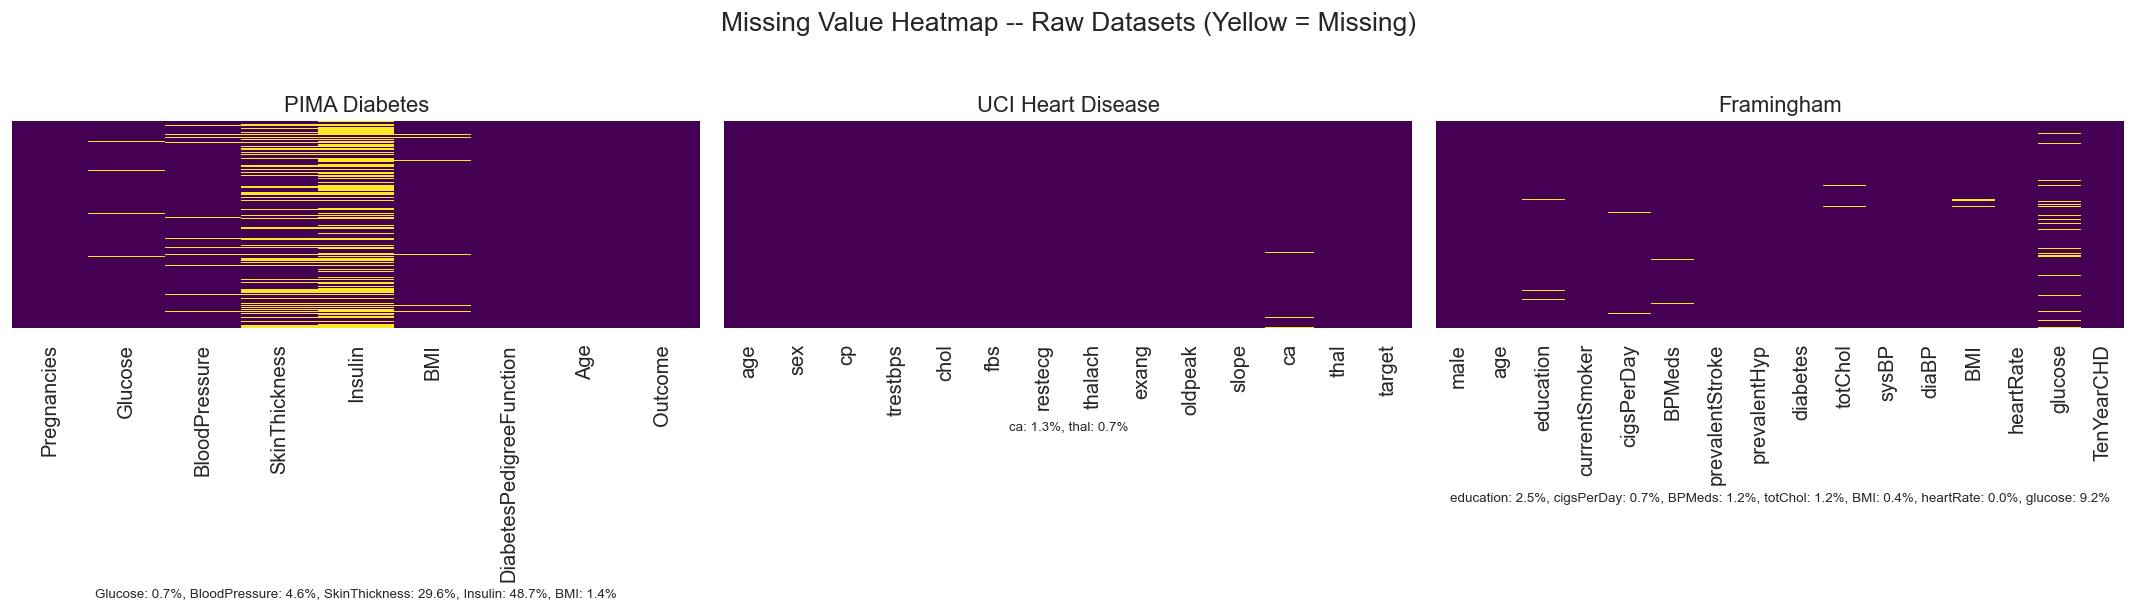

In [3]:
raw_datasets = {
    'PIMA Diabetes'       : pima,
    'UCI Heart Disease'   : heart,
    'Framingham'          : fram,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, df) in zip(axes, raw_datasets.items()):
    # Replace impossible zeros in PIMA for honest missingness display
    display_df = df.copy()
    if name == 'PIMA Diabetes':
        for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
            display_df[col] = display_df[col].replace(0, np.nan)
    sns.heatmap(display_df.isnull(), yticklabels=False, cbar=False,
                cmap='viridis', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Columns')
    missing_pct = display_df.isnull().mean() * 100
    missing_pct = missing_pct[missing_pct > 0].round(1)
    if not missing_pct.empty:
        note = ', '.join([f'{c}: {v}%' for c, v in missing_pct.items()])
        ax.set_xlabel(note, fontsize=8)

plt.suptitle('Missing Value Heatmap -- Raw Datasets (Yellow = Missing)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '01_missing_heatmap.png'))
plt.show()


## 3. Class Balance Analysis

Checks whether the target labels are balanced or skewed. Significant imbalance may require SMOTE or class weighting during training.


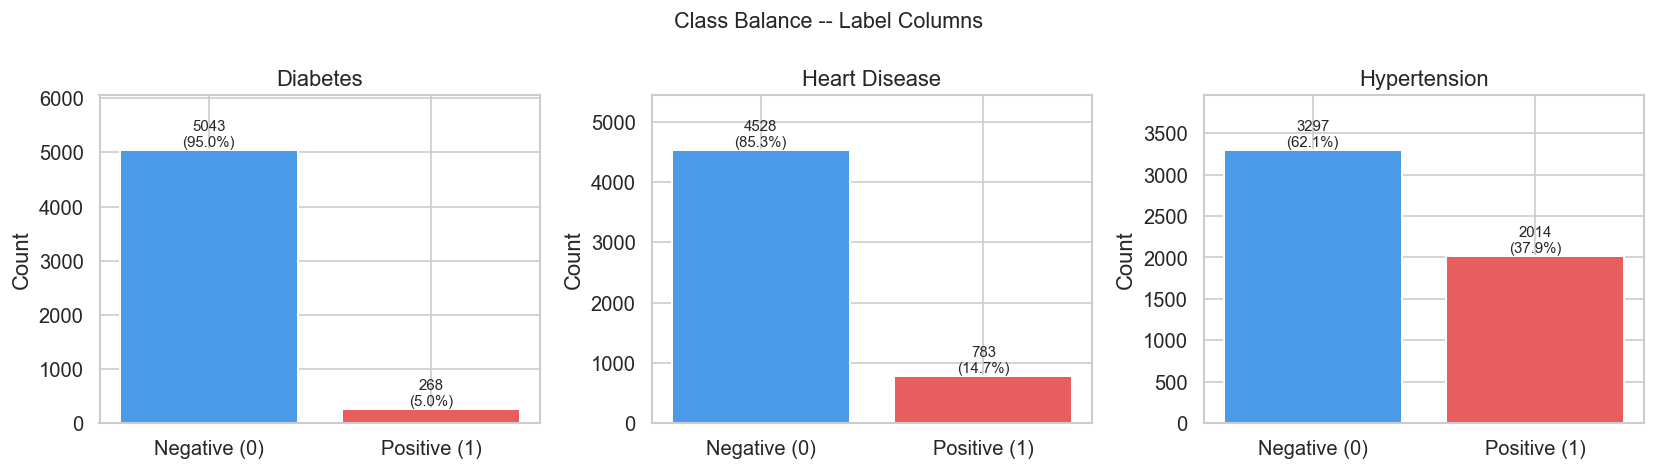

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Diabetes', 'Heart Disease', 'Hypertension']
colors = [['#4C9BE8', '#E85D5D'], ['#4C9BE8', '#E85D5D'], ['#4C9BE8', '#E85D5D']]

for ax, col, title, clr in zip(axes, LABEL_COLS, titles, colors):
    counts = master[col].value_counts().sort_index()
    bars = ax.bar(['Negative (0)', 'Positive (1)'], counts.values,
                  color=clr, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val}\n({val/len(master)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Class Balance -- Label Columns', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '02_class_balance.png'))
plt.show()


## 4. Feature Distributions (Histogram + KDE)

Shows the distribution shape of each continuous feature across the master dataset. Skewed features may benefit from log transformation before modelling.


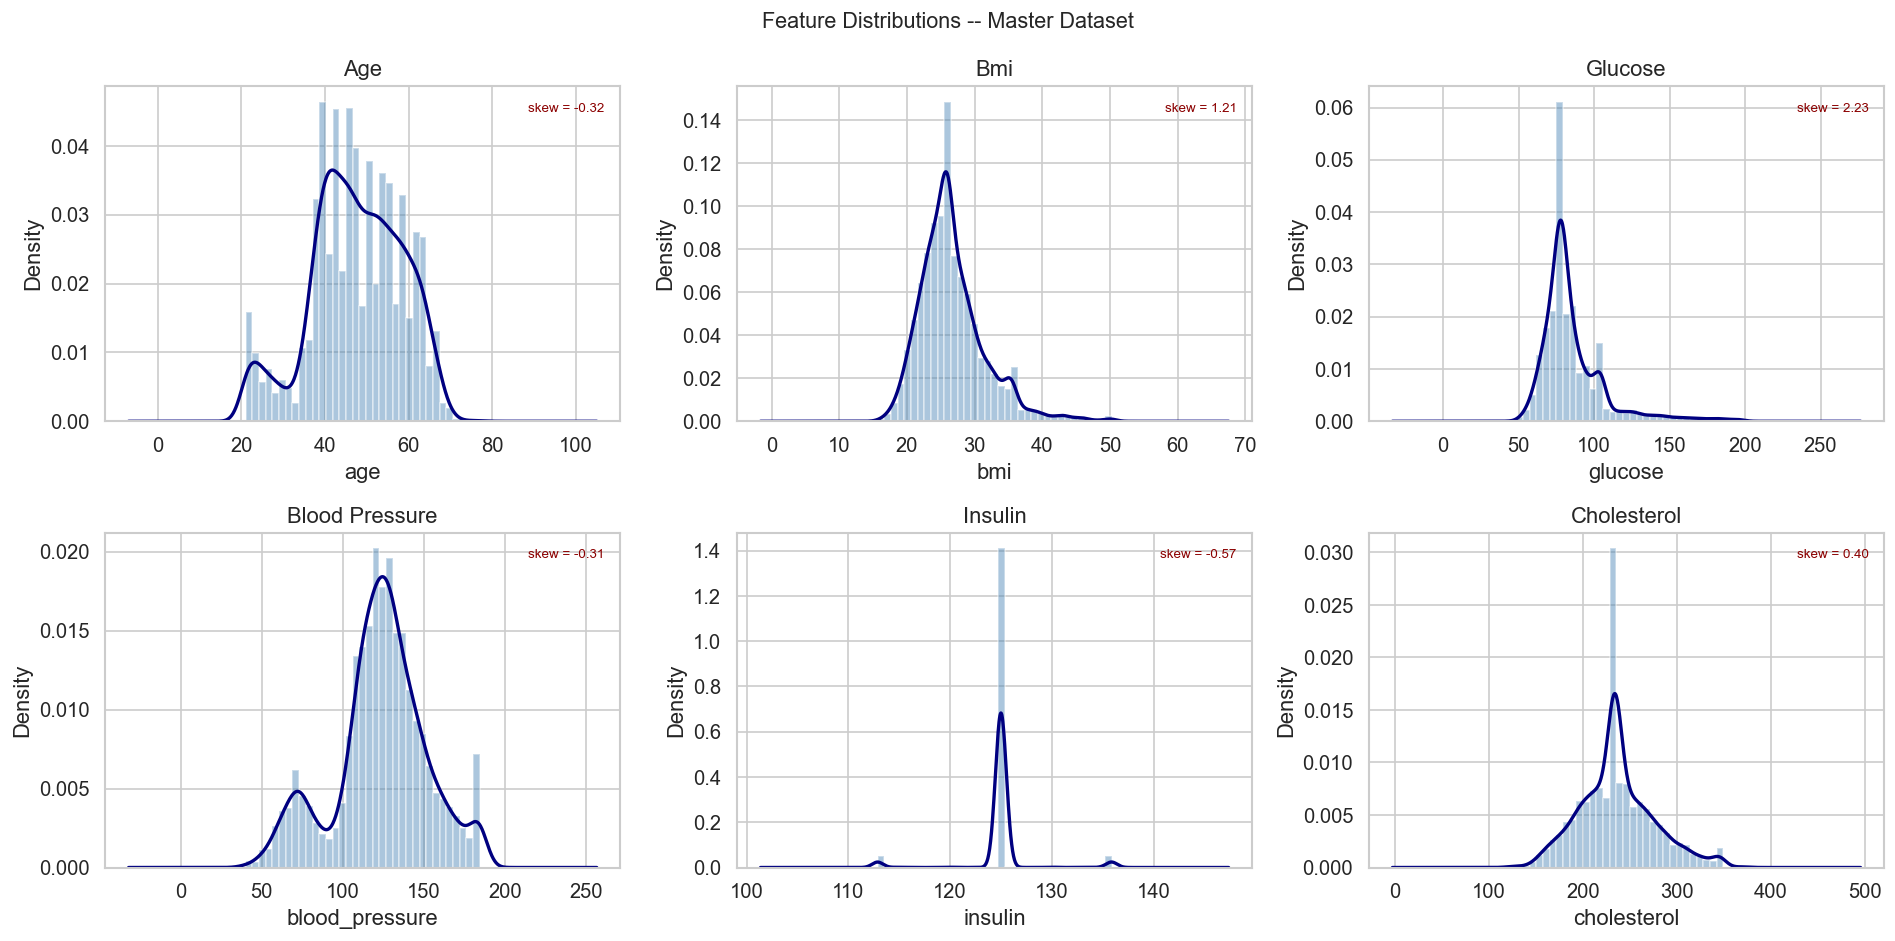

In [5]:
feat_cols = [c for c in FEATURES if c in master.columns]
n = len(feat_cols)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, feat_cols):
    data = master[col].dropna()
    ax.hist(data, bins=35, density=True, alpha=0.45,
            color='steelblue', edgecolor='white')
    data.plot.kde(ax=ax, color='navy', linewidth=2)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    skew = data.skew()
    ax.annotate(f'skew = {skew:.2f}', xy=(0.97, 0.95),
                xycoords='axes fraction', ha='right', va='top', fontsize=8,
                color='darkred')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Feature Distributions -- Master Dataset', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_distributions.png'))
plt.show()


## 5. Boxplots -- Outlier Visualisation

Boxplots show the spread and remaining outliers after IQR capping. Also shows feature distribution broken down by data source.


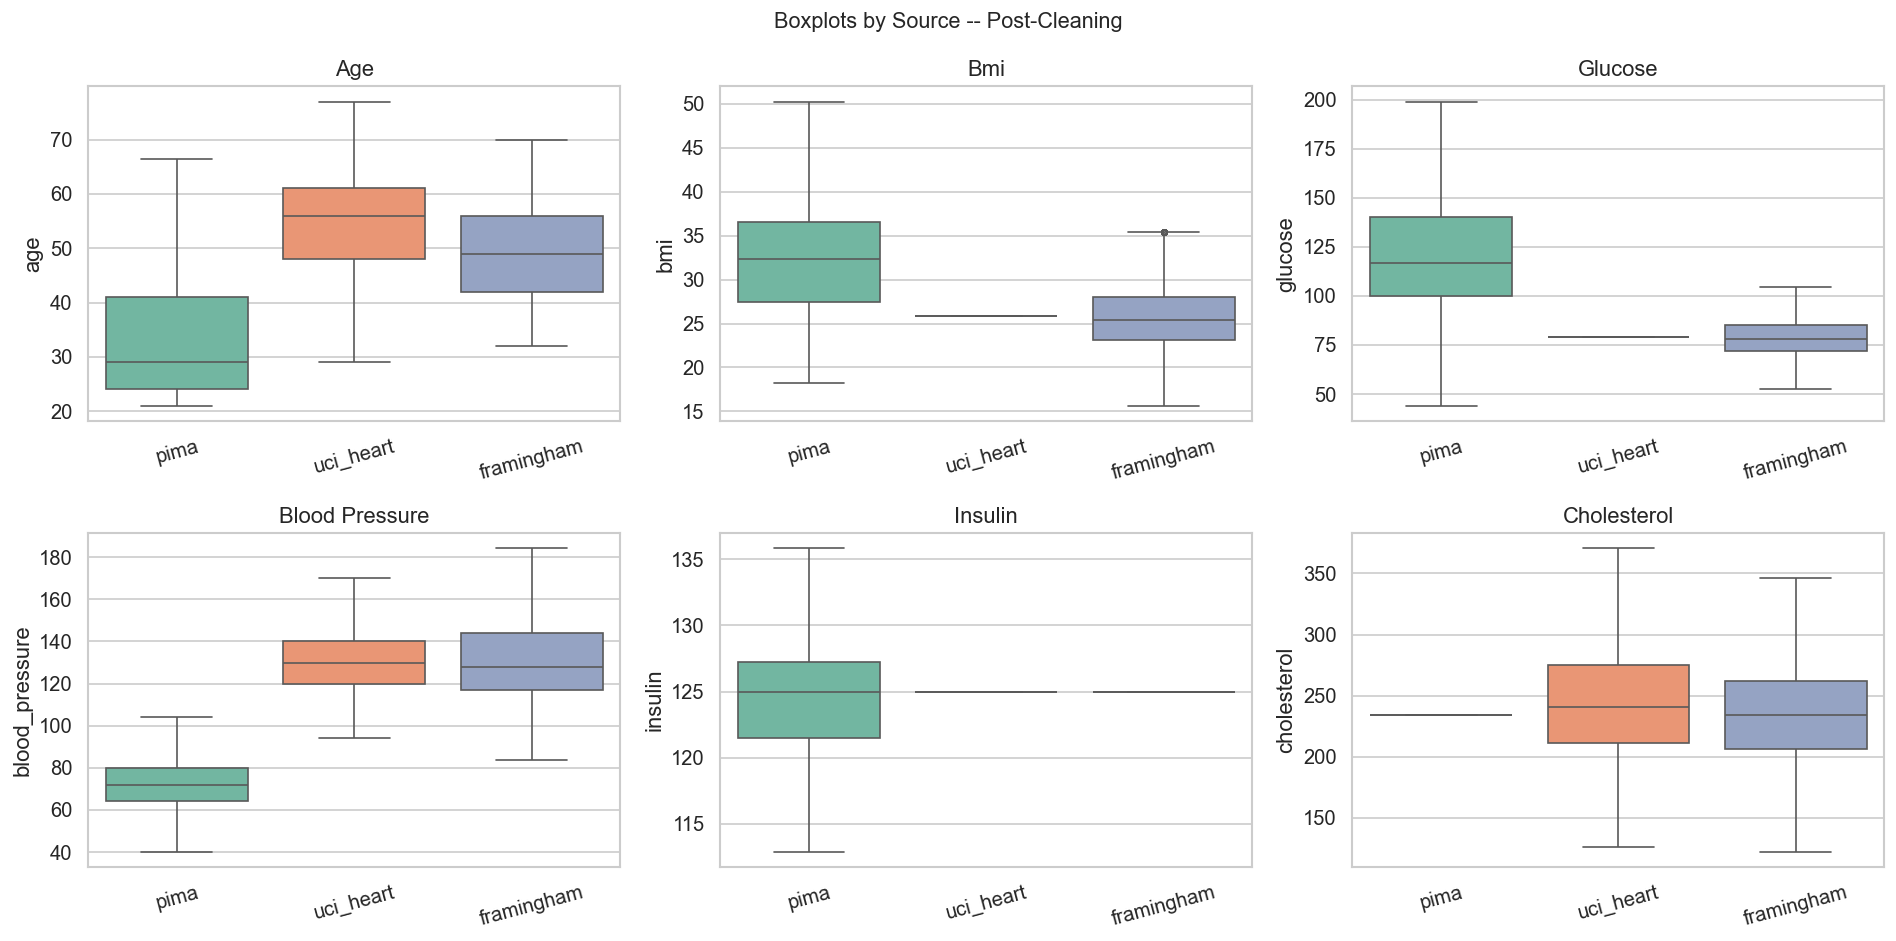

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, feat_cols):
    source_order = master['source'].unique().tolist()
    sns.boxplot(data=master, x='source', y=col, ax=ax,
                palette='Set2', order=source_order,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Boxplots by Source -- Post-Cleaning', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '04_boxplots.png'))
plt.show()


## 6. Correlation Heatmap

Pearson correlation matrix across all numeric features and label columns. Highlights multicollinearity and the strength of feature-label relationships.


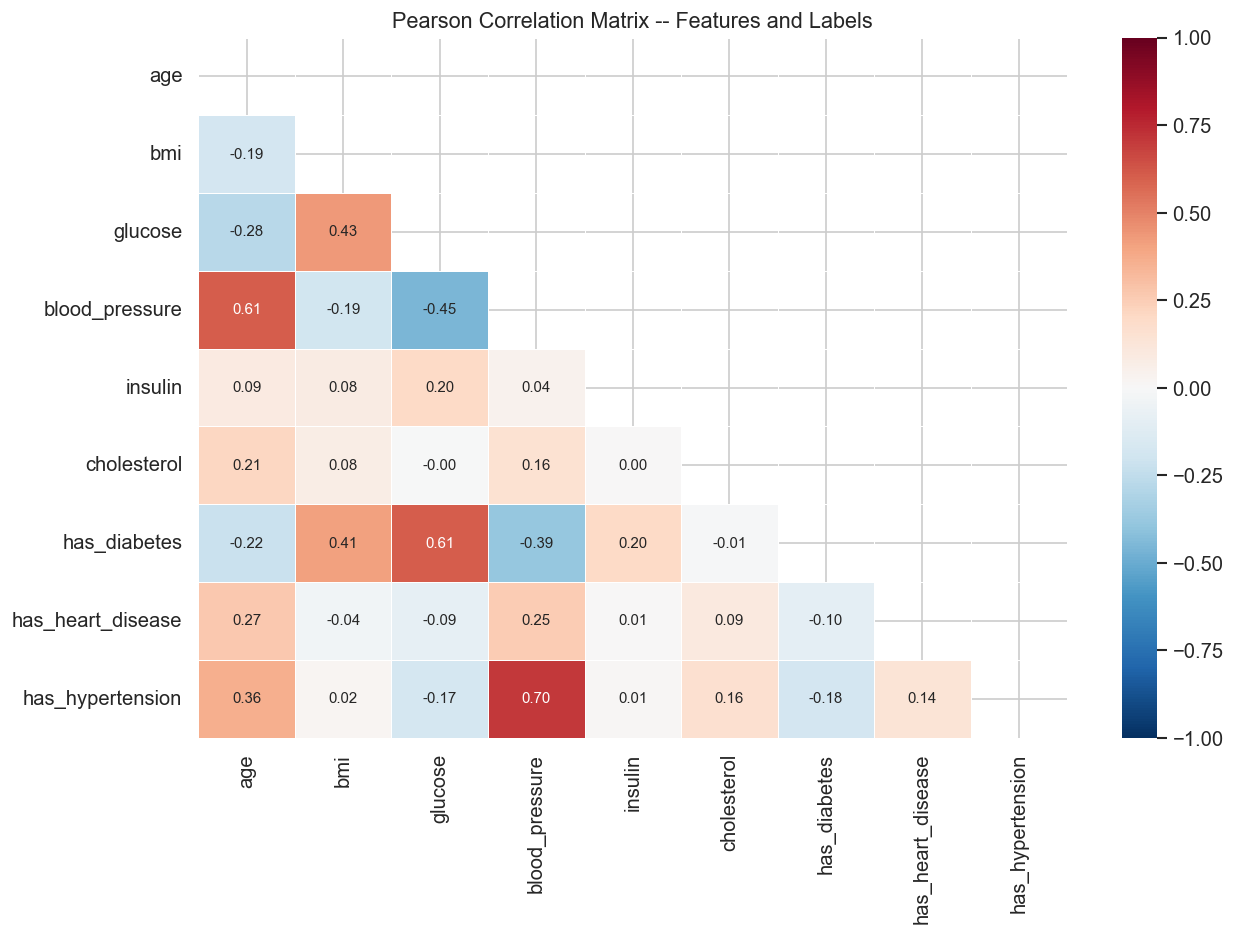

In [9]:
corr_cols = feat_cols + LABEL_COLS
corr_matrix = master[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Pearson Correlation Matrix -- Features and Labels', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '05_correlation_heatmap.png'))
plt.show()


## 7. Pairplot

Pairwise scatter plots coloured by diabetes label to reveal separability and inter-feature relationships. Subset to PIMA rows for a clean single-label view.


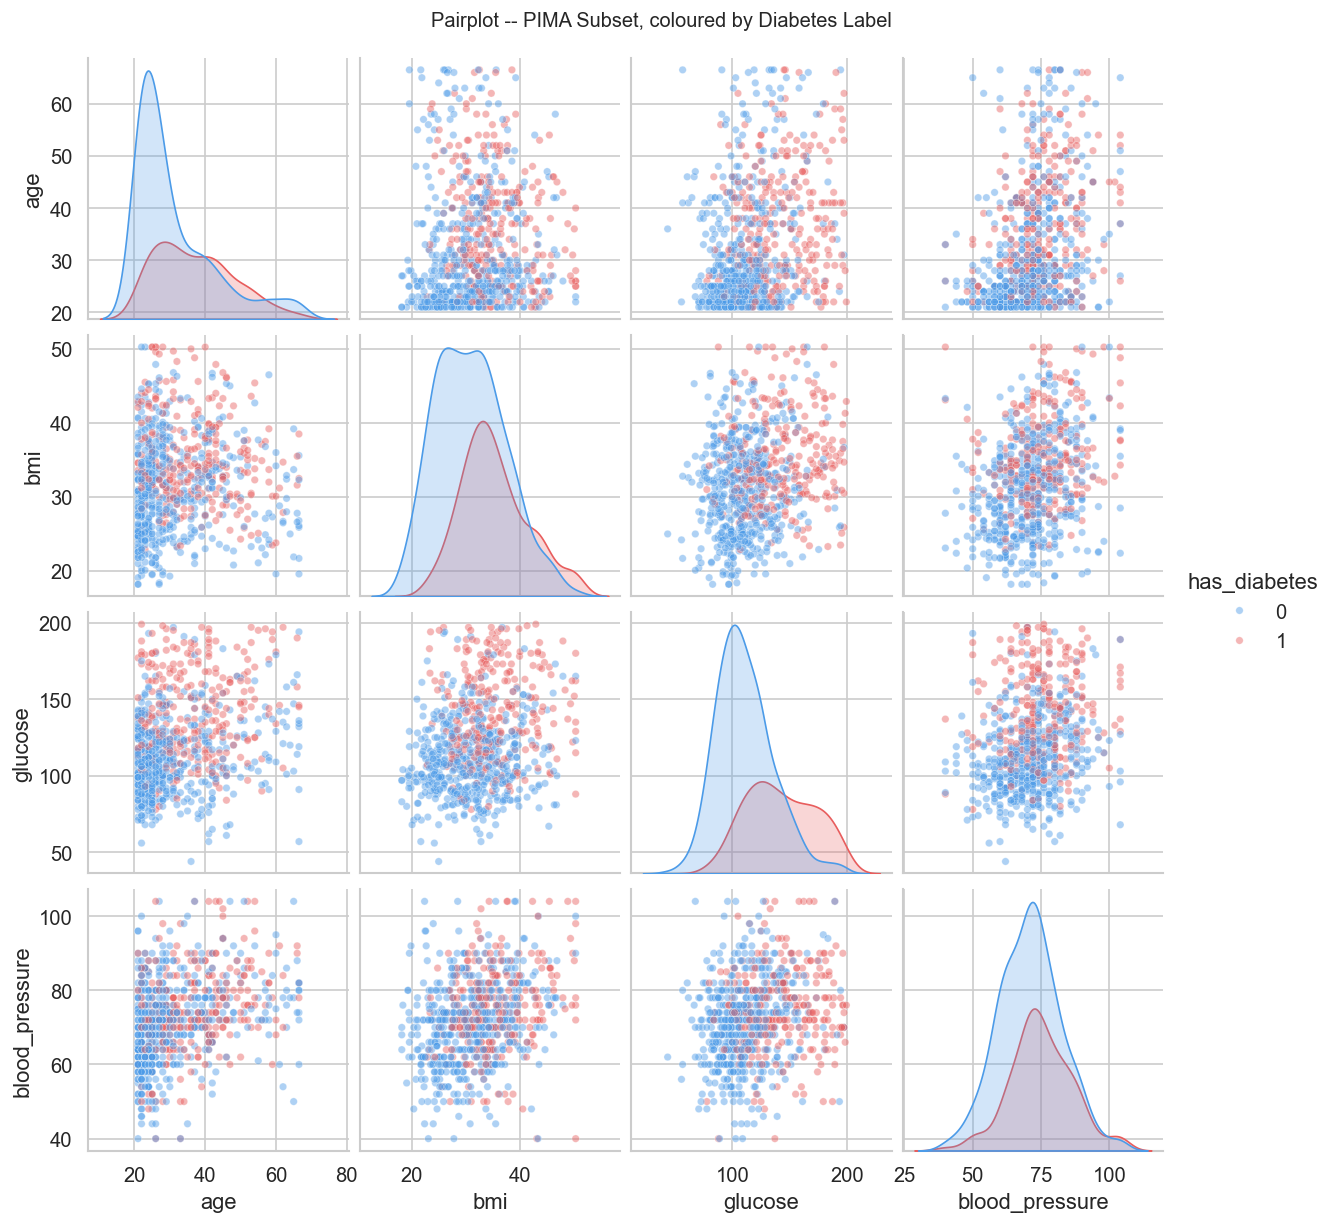

In [10]:
pima_subset = master[master['source'] == 'pima'][feat_cols + ['has_diabetes']].dropna()

pair_cols = ['age', 'bmi', 'glucose', 'blood_pressure']
pair_cols = [c for c in pair_cols if c in pima_subset.columns]

g = sns.pairplot(
    pima_subset[pair_cols + ['has_diabetes']],
    hue='has_diabetes',
    palette={0: '#4C9BE8', 1: '#E85D5D'},
    plot_kws={'alpha': 0.45, 's': 20},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot -- PIMA Subset, coloured by Diabetes Label',
               y=1.02, fontsize=12)
g.fig.savefig(os.path.join(FIGS_DIR, '06_pairplot.png'))
plt.show()


## 8. Feature-Target Relationship Analysis

Violin plots showing the distribution of each feature split by the diabetes label. This gives an early indication of which features are most discriminative.


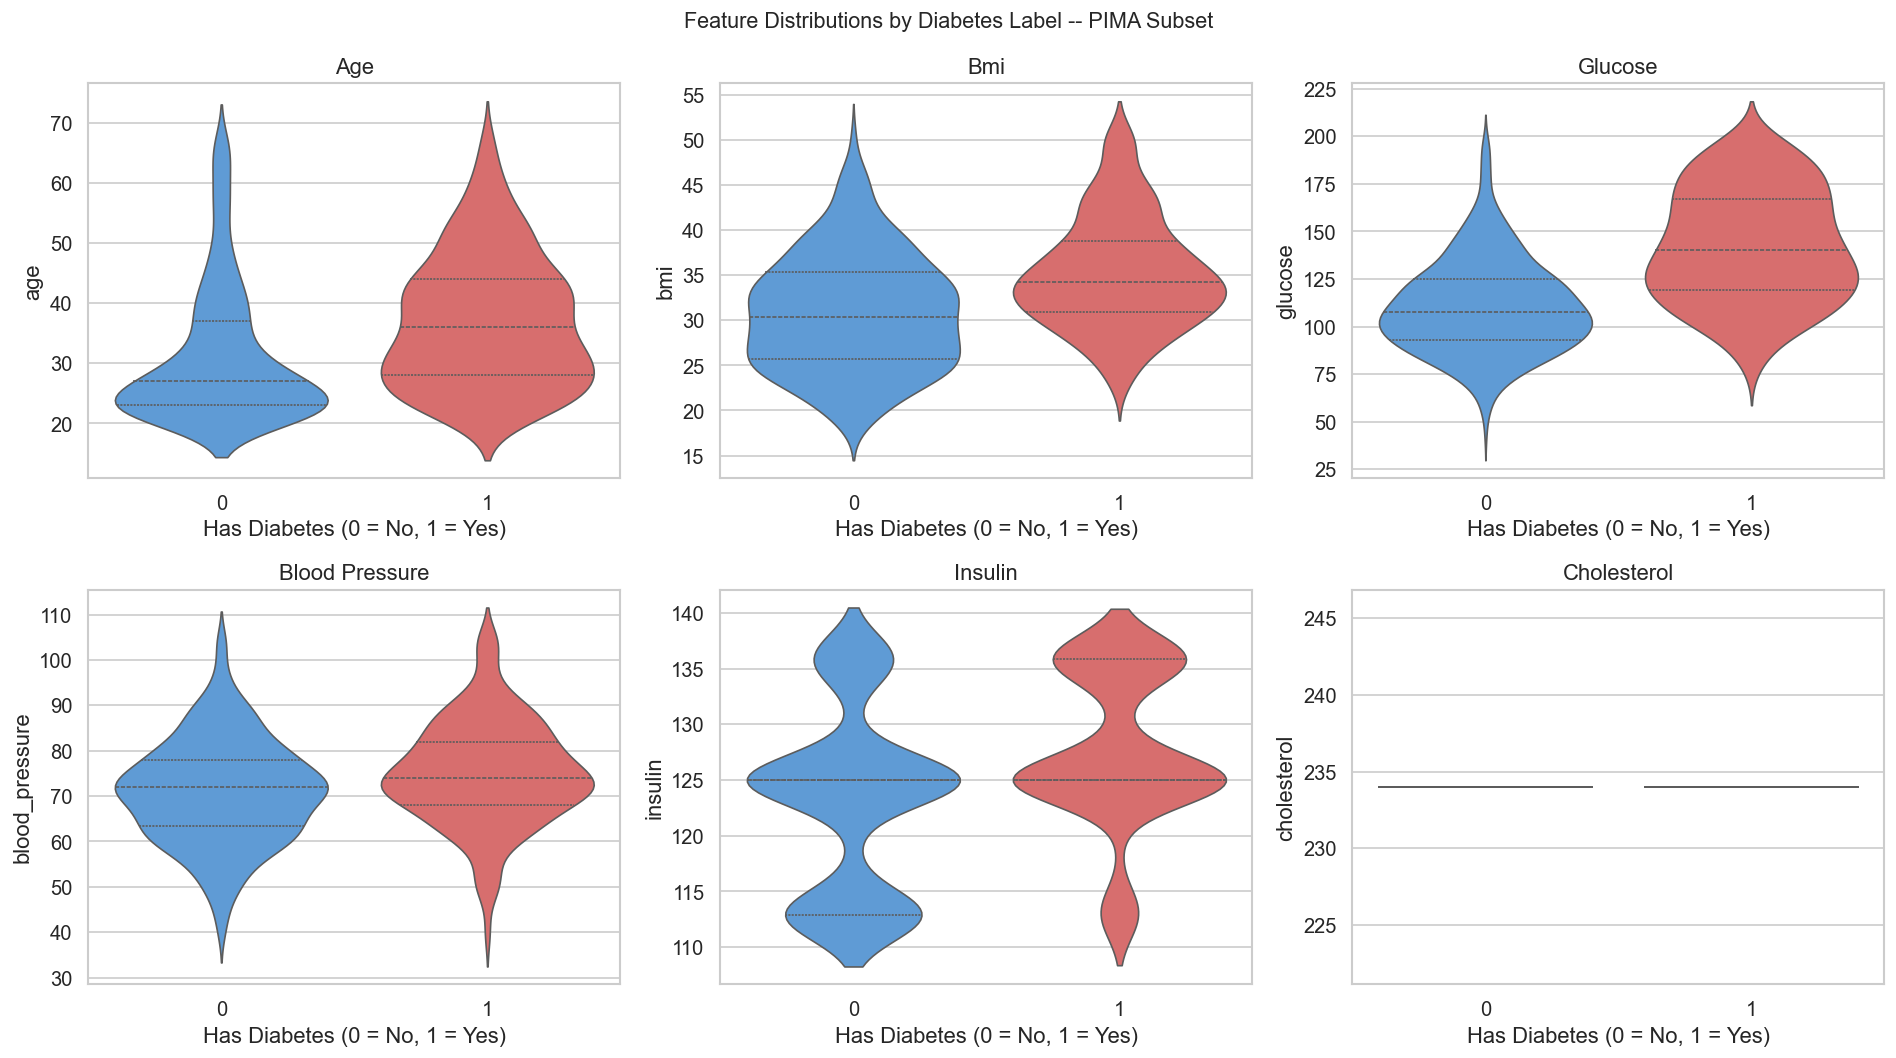

In [14]:
pima_clean = master[master['source'] == 'pima'].copy()
pima_clean['has_diabetes'] = pima_clean['has_diabetes'].astype(int)
plot_feats = [c for c in feat_cols if c in pima_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, plot_feats):
    sns.violinplot(
        data=pima_clean, x='has_diabetes', y=col, ax=ax,
        palette=['#4C9BE8', '#E85D5D'],
        inner='quartile', linewidth=1
    )
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Has Diabetes (0 = No, 1 = Yes)')
    ax.set_ylabel(col)

for ax in axes[len(plot_feats):]:
    ax.set_visible(False)

plt.suptitle('Feature Distributions by Diabetes Label -- PIMA Subset', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '07_violin_feature_target.png'))
plt.show()

## 9. Source Distribution Analysis

Shows how many rows each source contributes to the master dataset and the age distribution per source to check for demographic alignment.


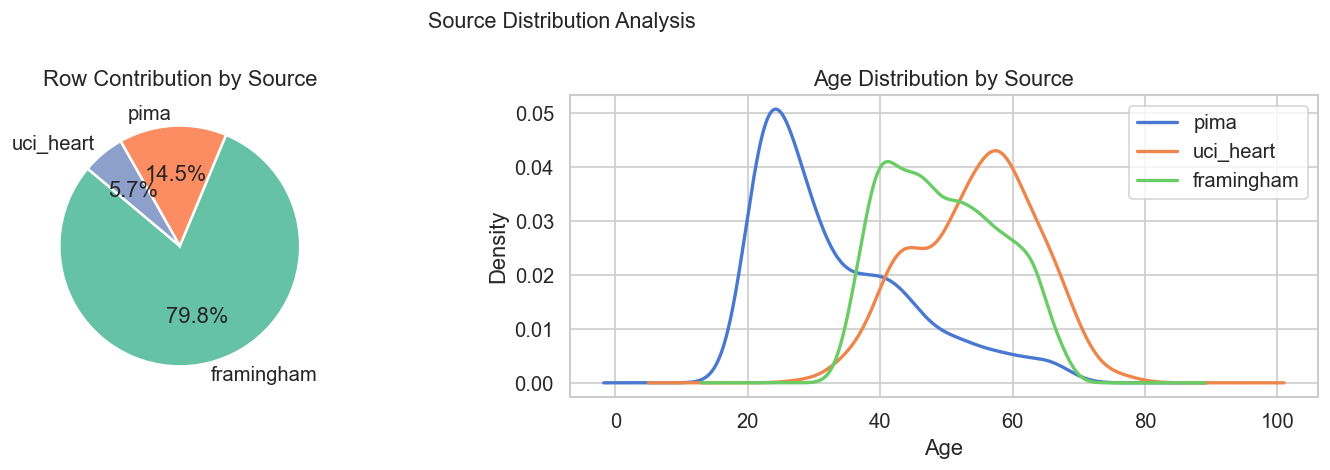

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#  Pie chart: row contribution 
src_counts = master['source'].value_counts()
axes[0].pie(
    src_counts.values,
    labels=src_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(src_counts)),
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Row Contribution by Source')

#  KDE: age distribution per source 
for src in master['source'].unique():
    subset = master[master['source'] == src]['age'].dropna()
    subset.plot.kde(ax=axes[1], label=src, linewidth=2)
axes[1].set_title('Age Distribution by Source')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Source Distribution Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '08_source_distribution.png'))
plt.show()


## 10. EDA Summary

Key observations from the exploratory analysis:

| Observation | Implication |
|---|---|
| Glucose and BMI show clear separation between diabetic/non-diabetic groups | Strong predictive features for diabetes model |
| Insulin is highly right-skewed | Consider log transformation before training |
| Class imbalance present in all three label columns | Apply class weighting or SMOTE during training |
| Framingham dominates row count | Stratified splitting required to avoid source leakage |
| Age distributions differ across sources | Source-aware normalisation recommended |
| Several features moderately correlated (glucose-BMI, age-BP) | No severe multicollinearity; tree models handle this natively |
